# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 04     |  |
| :-------------|:-------------|
| Sriman Patlolla| 6393829 |
| Juraj Hadak| 5989779 |
| Carsten Schroevers| 6126634 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Sriman', 'Juraj','Carsten']

## Opdracht 1: Planning.

| Planning Groep: 04     |Tijdstip / Tijdspanne  |
|---|---|
| Voorbereiding af Arduino opzetten | 11.30 |
| Kalibratie en testen | 12.00 |
|  Zelf algoritme schrijven | 12.30 |
| Iteraties en testen | 15.00 |
| Eindtest en afronden | 16.30 |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| 12.30-13.30 |
| Pauze 2|  |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [04]
<img src="Foto.jpeg" width="400">

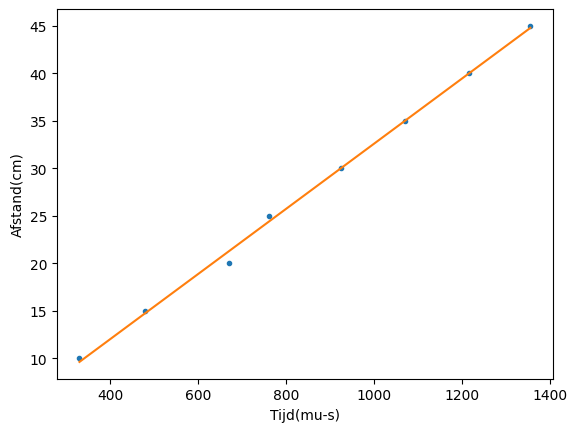

a en b zijn: [ 0.03429911 -1.68425201]


In [3]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

Afstand = np.array([10,15,20,25,30,35,40,45])
Tijd = np.array([330,480,670,761,925,1070,1216,1355])

def func(x,a,b):
    return a*x+b

popt, pcov = curve_fit(func, Tijd, Afstand)

Tijd_test = np.linspace(np.min(Tijd), np.max(Tijd),100)
Af_test = func(Tijd_test, *popt)

plt.figure()
plt.plot(Tijd, Afstand,'.')
plt.plot(Tijd_test, Af_test)
plt.xlabel("Tijd(mu-s)")
plt.ylabel("Afstand(cm)")
plt.show()

print("a en b zijn:",popt)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  40.5
1   0  30   0  20  40.6
2   0  10   0  20  45.1
3  40   0  30   0  41.2
4  30   0  20   0  40.8
5  10   0  20   0  45.0
6  10   0   0  10  45.0


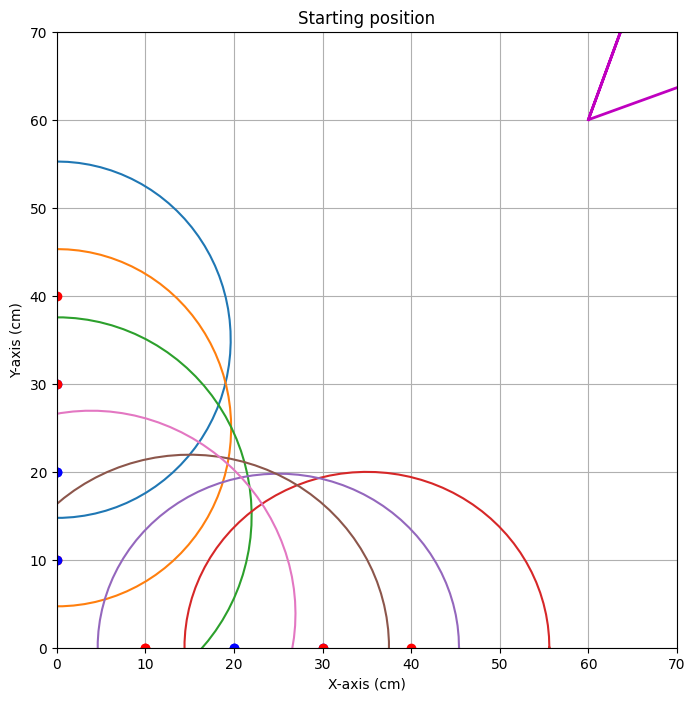


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=106.994


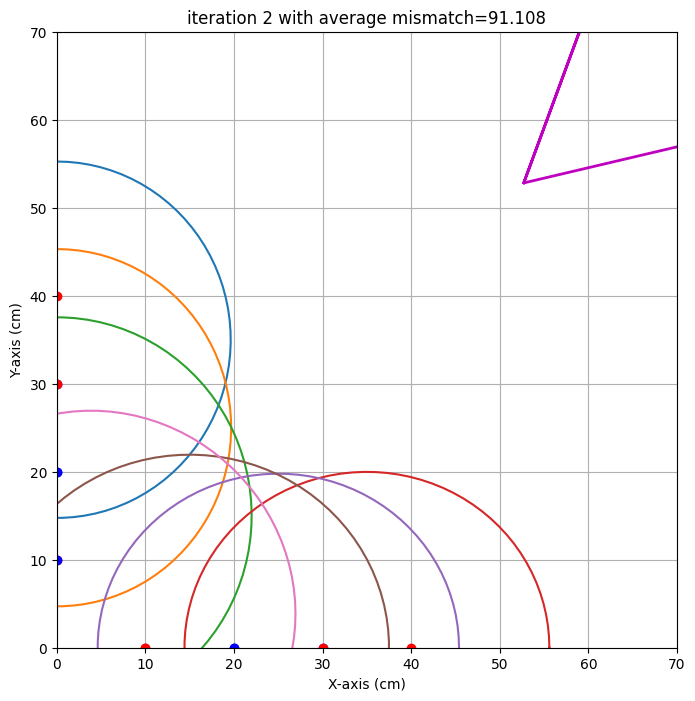

end iteration 2 with average mismatch=91.108


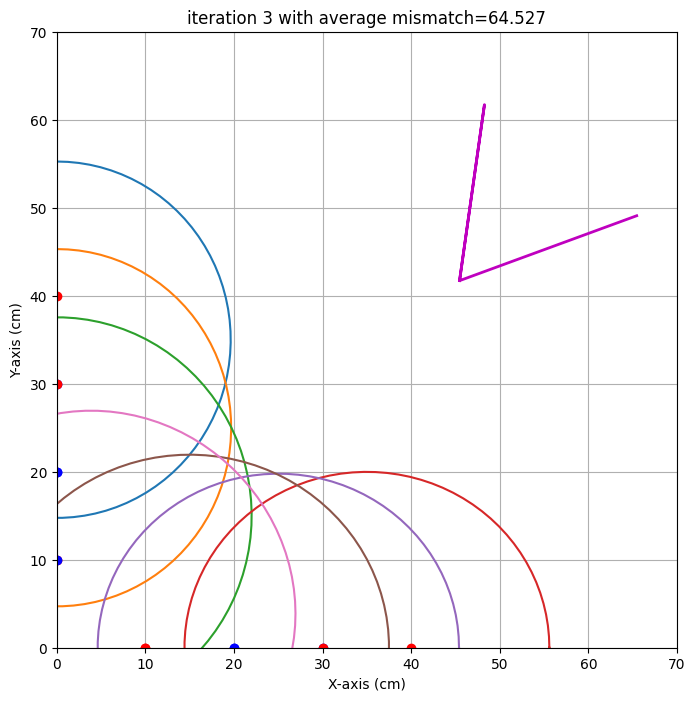

end iteration 3 with average mismatch=64.527


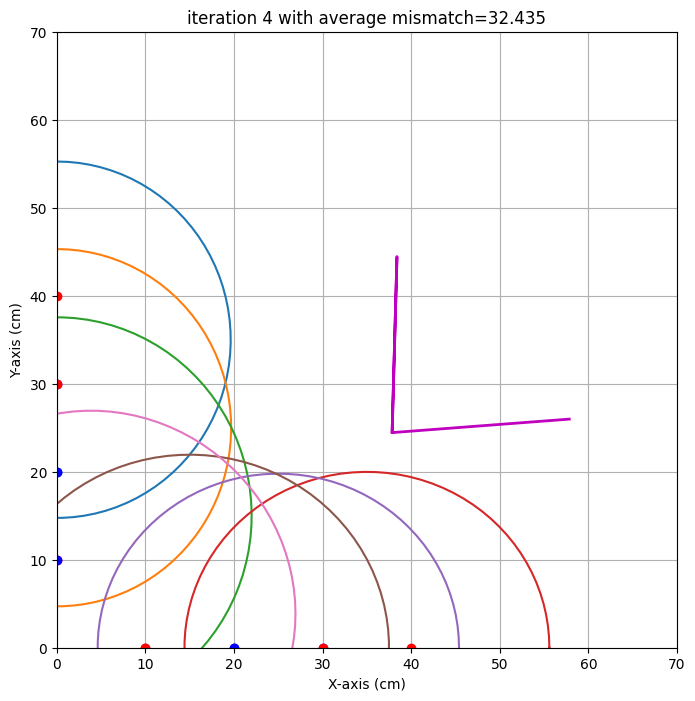

end iteration 4 with average mismatch=32.435


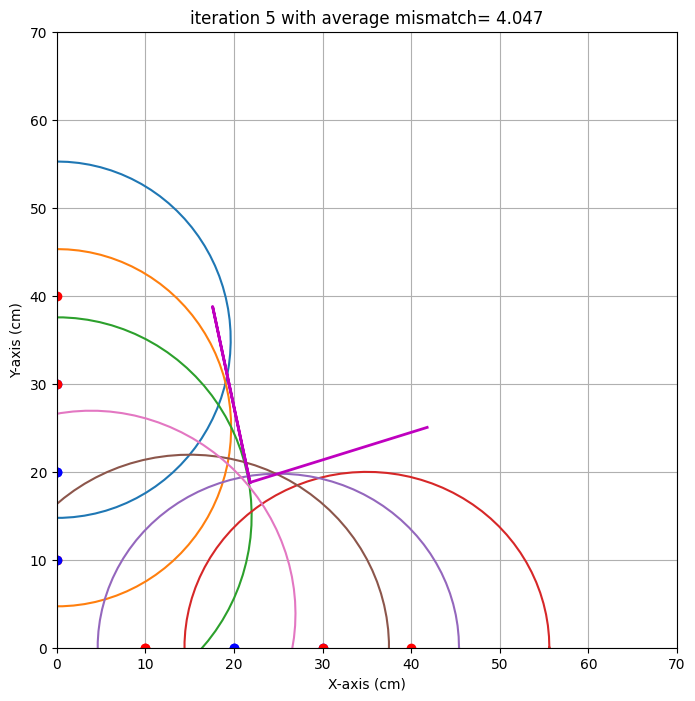

end iteration 5 with average mismatch= 4.047


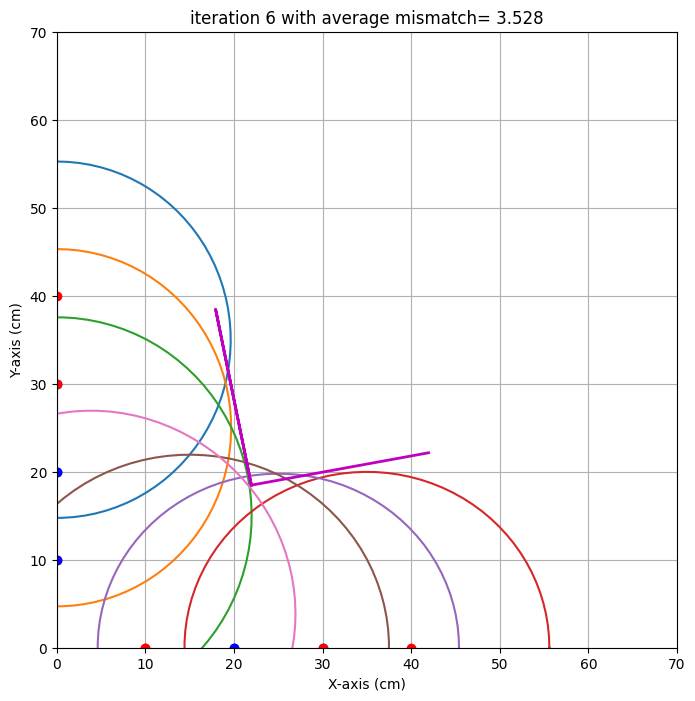

end iteration 6 with average mismatch= 3.528


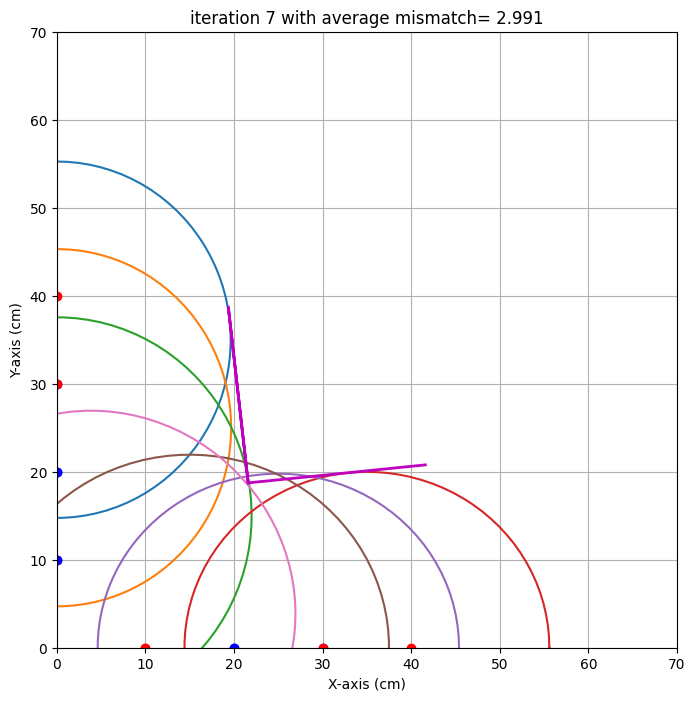

end iteration 7 with average mismatch= 2.991
end iteration 8 with average mismatch= 2.985
end iteration 9 with average mismatch= 2.919
end iteration 10 with average mismatch= 2.870
end iteration 11 with average mismatch= 2.745
end iteration 12 with average mismatch= 2.710
end iteration 13 with average mismatch= 2.699
end iteration 14 with average mismatch= 2.698
end iteration 15 with average mismatch= 2.698
end iteration 16 with average mismatch= 2.697
end iteration 17 with average mismatch= 2.697
end iteration 18 with average mismatch= 2.697
end iteration 19 with average mismatch= 2.671
end iteration 20 with average mismatch= 2.671
end iteration 21 with average mismatch= 2.671
end iteration 22 with average mismatch= 2.671
end iteration 23 with average mismatch= 2.671
end iteration 24 with average mismatch= 2.670
end iteration 25 with average mismatch= 2.669
end iteration 26 with average mismatch= 2.667
end iteration 27 with average mismatch= 2.663
end iteration 28 with average mismatc

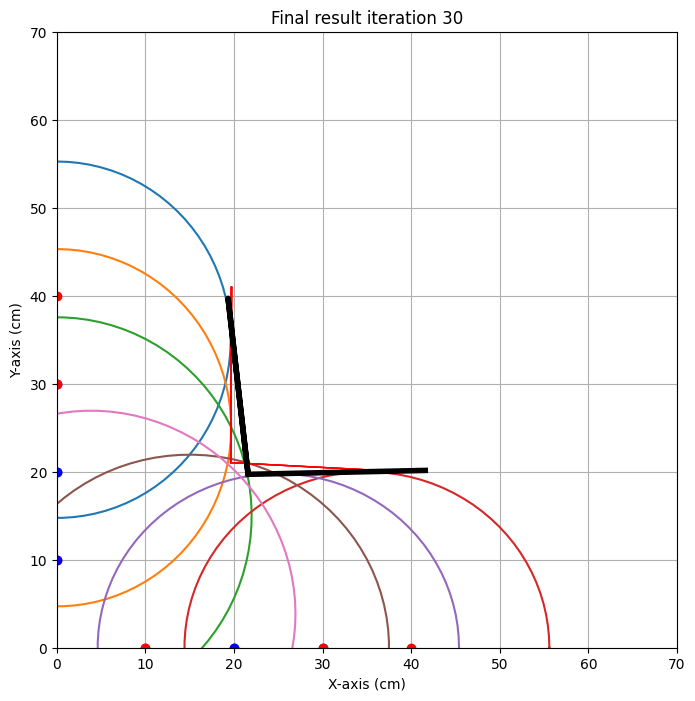

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,40.5],
    [0,30,0,20,40.6],
    [0,10,0,20,45.1],
    [40,0,30,0,41.2],
    [30,0,20,0,40.8],
    [10,0,20,0,45],
    [10,0,0,10,45]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.6 cm met een standaardafwijking van 2.0 cm 
y0: 19.7 cm met een standaardafwijking van 1.3 cm 
alpha: 1.3 graden met een standaardafwijking van 4.3 graad 
beta: -6.5 graden met een standaardafwijking van 6.7 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Sriman]

<img src="Alg1.jpeg" width="400">

#### algoritme [Juraj]

<img src="Alg2.jpeg" width="400">

#### algoritme [Carsten]

<img src="Alg3.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 20,
           'y0':20,
           'alpha' : 10,
           'beta' : 5,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={
       'Sriman' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [25,0,40,0,43.58],
    [25,0,35,0,43.39],
    [25,0,30,0,41.60],
    [0,25,0,40,43.80],
    [0,25,0,35,41.38],
    [0,25,0,30,39.90]
    ]),
       'Juraj' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,45,0,45.9],
    [35,0,40,0,43.8],
    [30,0,35,0,42.2],
    [25,0,30,0,40.9],
    [0,40,0,45,41.7],
    [0,35,0,40,40.8],
    [0,30,0,35,40.1],
    [0,25,0,30,39.3]
    ])
      }

## Opdracht 7: Evaluatie.

Sriman
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  25   0  40   0  43.58
1  25   0  35   0  43.39
2  25   0  30   0  41.60
3   0  25   0  40  43.80
4   0  25   0  35  41.38
5   0  25   0  30  39.90


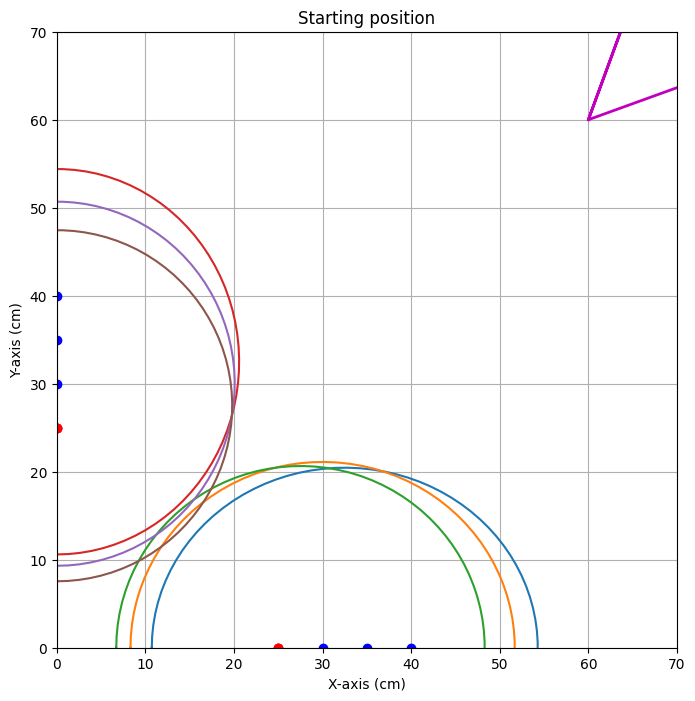


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.505


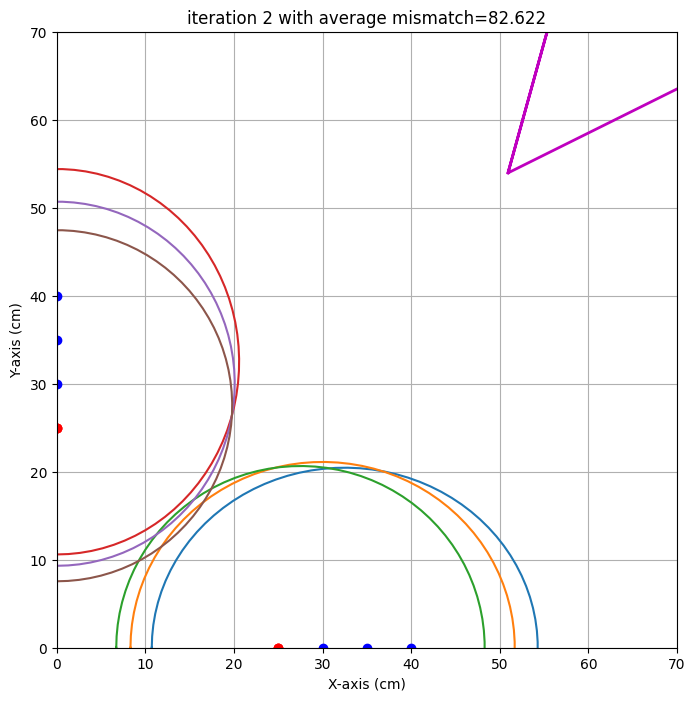

end iteration 2 with average mismatch=82.622


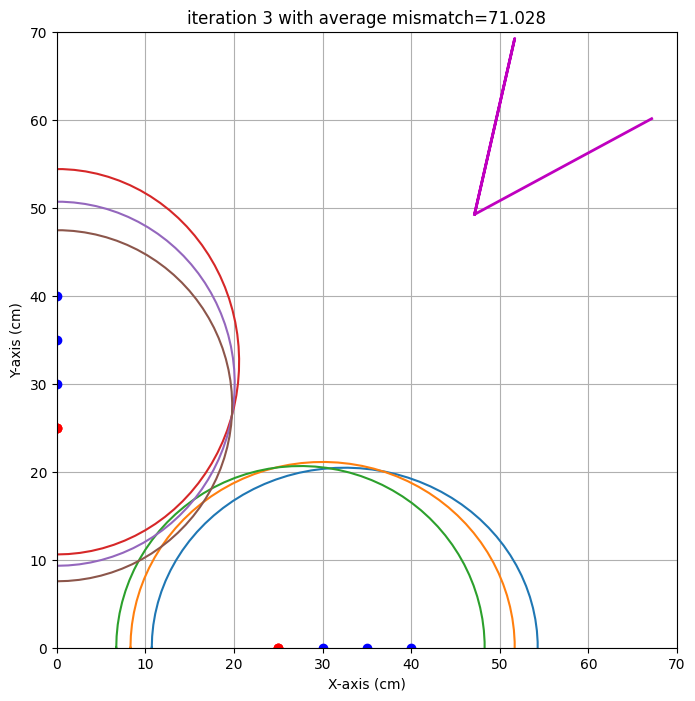

end iteration 3 with average mismatch=71.028


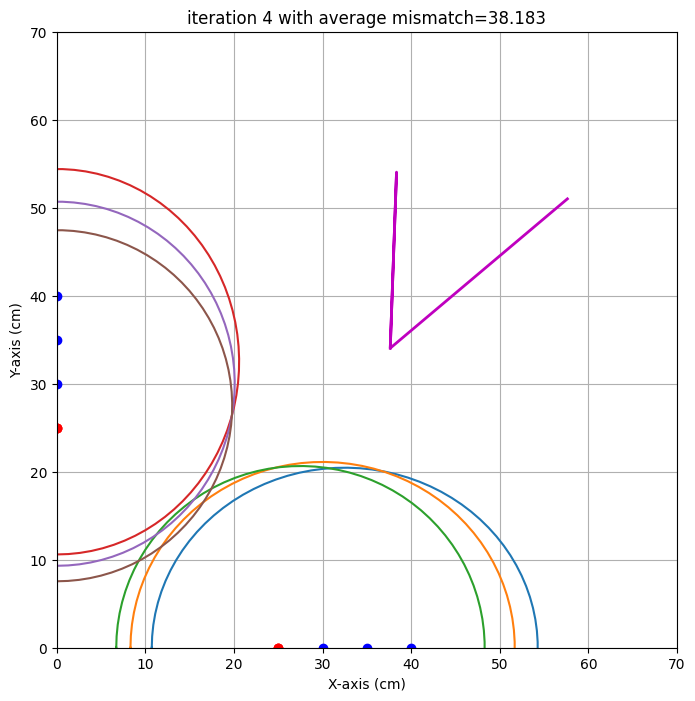

end iteration 4 with average mismatch=38.183


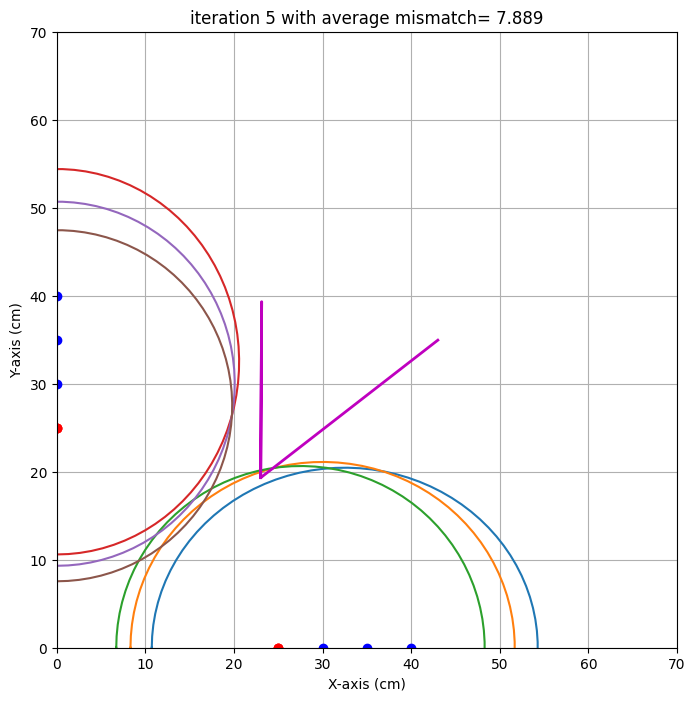

end iteration 5 with average mismatch= 7.889


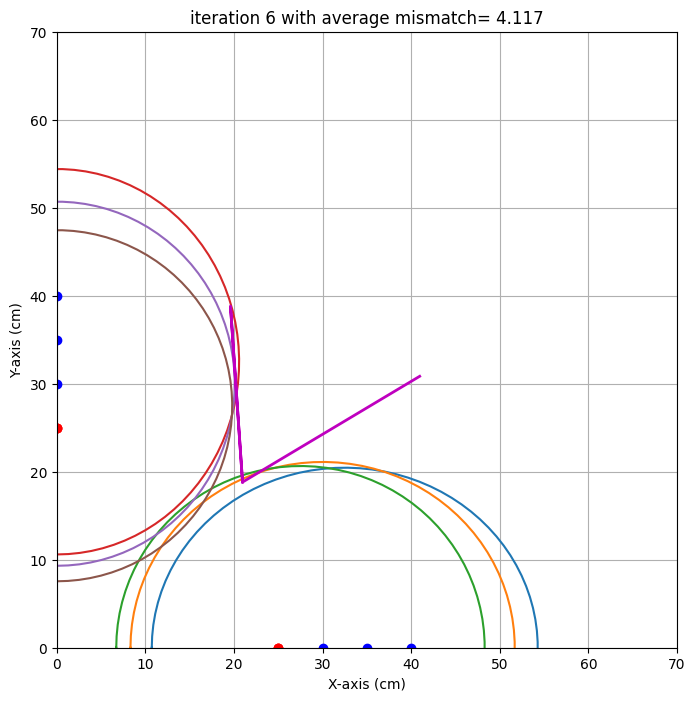

end iteration 6 with average mismatch= 4.117


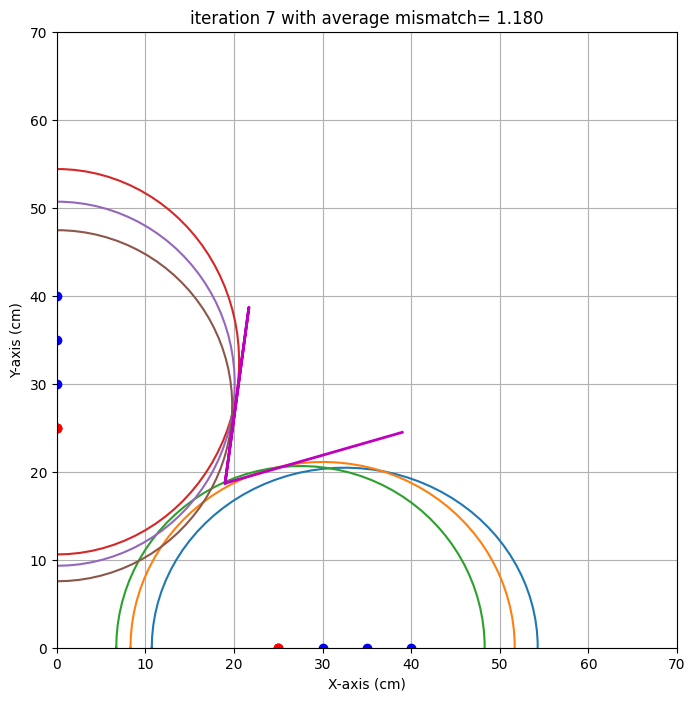

end iteration 7 with average mismatch= 1.180


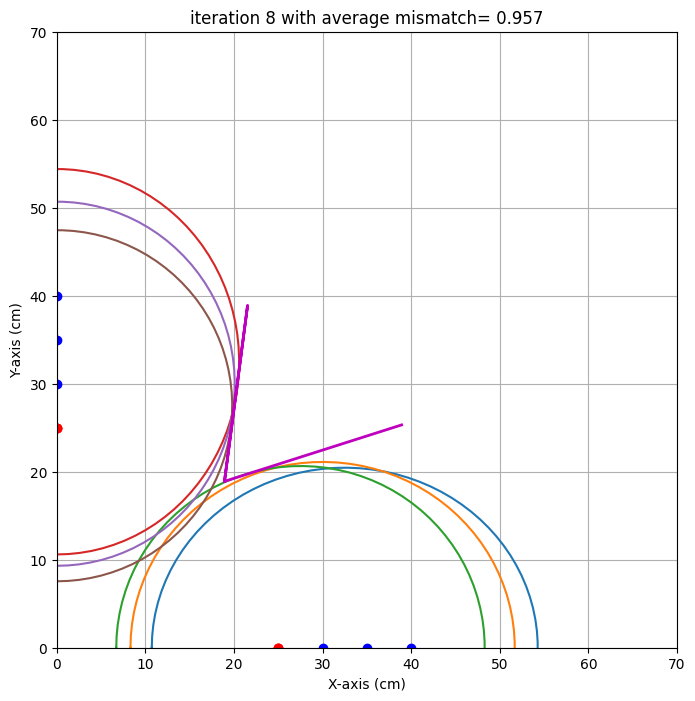

end iteration 8 with average mismatch= 0.957
end iteration 9 with average mismatch= 0.890
end iteration 10 with average mismatch= 0.841
end iteration 11 with average mismatch= 0.838
end iteration 12 with average mismatch= 0.836
end iteration 13 with average mismatch= 0.836
end iteration 14 with average mismatch= 0.836
end iteration 15 with average mismatch= 0.836
end iteration 16 with average mismatch= 0.836


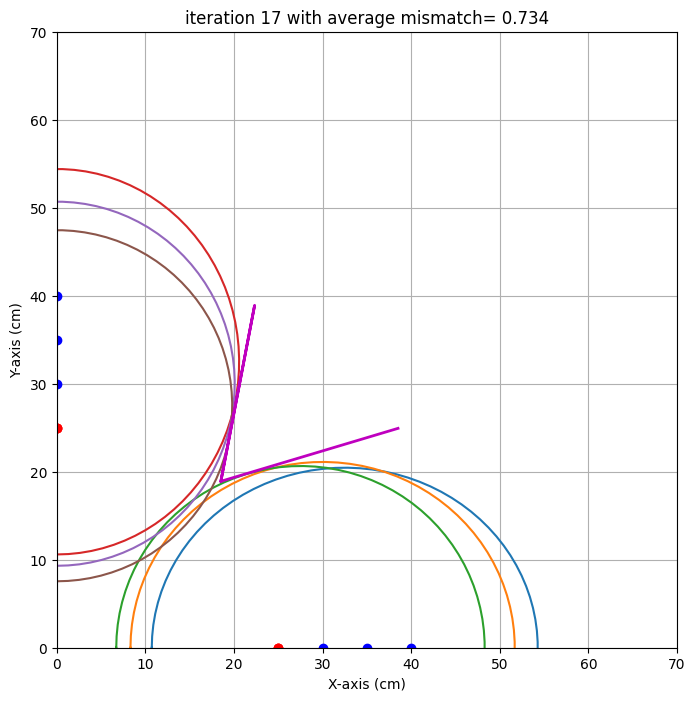

end iteration 17 with average mismatch= 0.734
end iteration 18 with average mismatch= 0.729
end iteration 19 with average mismatch= 0.728
end iteration 20 with average mismatch= 0.727
end iteration 21 with average mismatch= 0.727
end iteration 22 with average mismatch= 0.727
end iteration 23 with average mismatch= 0.727
end iteration 24 with average mismatch= 0.727
end iteration 25 with average mismatch= 0.727
end iteration 26 with average mismatch= 0.727
end iteration 27 with average mismatch= 0.727
end iteration 28 with average mismatch= 0.727
end iteration 29 with average mismatch= 0.727
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.727
###############################################################################
end of iteration  30
Best alpha=  16.74 with uncertainty=  14.66
Best beta =  10.79 with uncertainty=  11.68
Best x0   =  18.51 with uncertainty=   2.27
Best y0   =  1

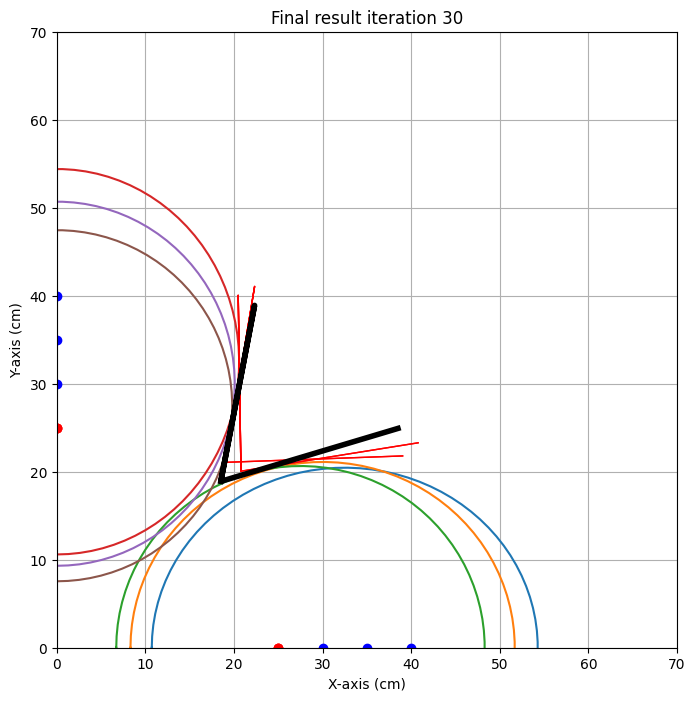

{'alpha': np.float64(16.74470695385061), 'alpha_eps': np.float64(14.659013988023831), 'beta': np.float64(10.790360713335419), 'beta_eps': np.float64(11.681955667375524), 'x0': np.float64(18.50676785104132), 'x0_eps': np.float64(2.274418756103856), 'y0': np.float64(18.903570974792274), 'y0_eps': np.float64(2.1621091816575024)}
Juraj
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  45   0  45.9
1  35   0  40   0  43.8
2  30   0  35   0  42.2
3  25   0  30   0  40.9
4   0  40   0  45  41.7
5   0  35   0  40  40.8
6   0  30   0  35  40.1
7   0  25   0  30  39.3


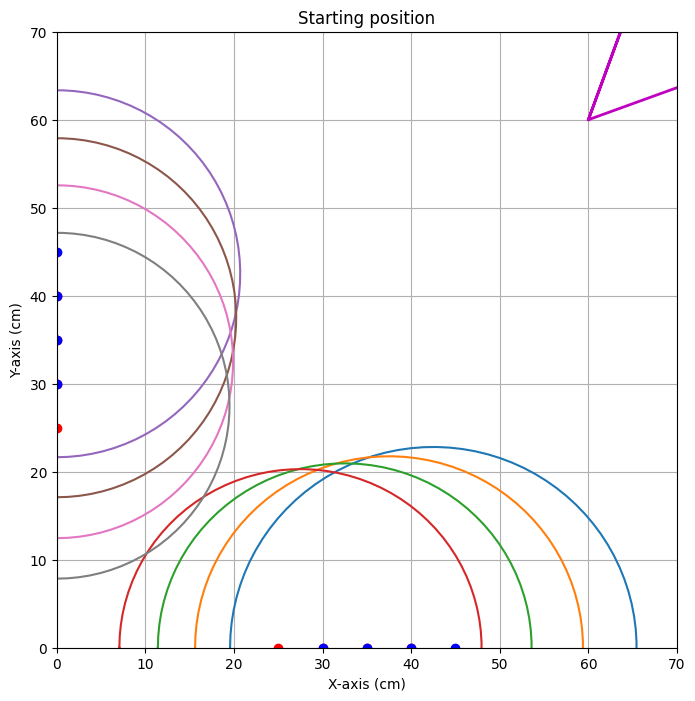


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=95.666
end iteration 2 with average mismatch=88.279


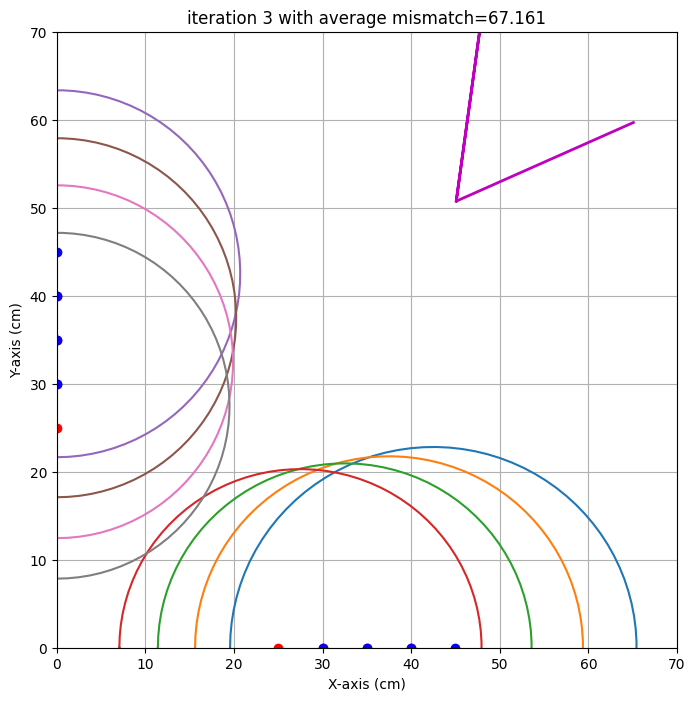

end iteration 3 with average mismatch=67.161


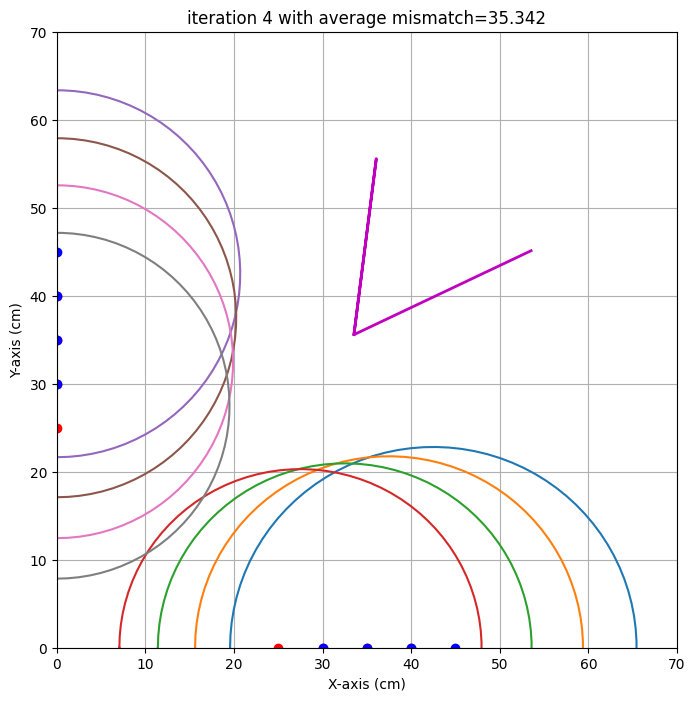

end iteration 4 with average mismatch=35.342


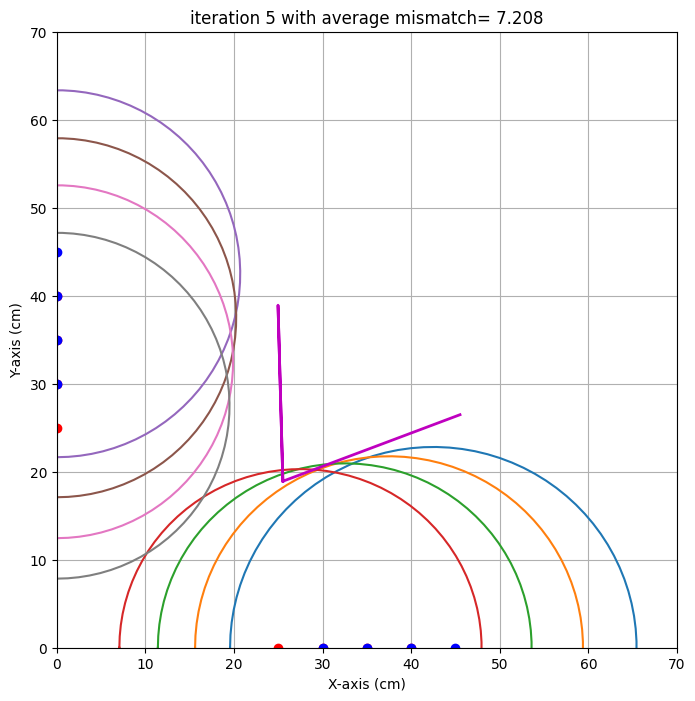

end iteration 5 with average mismatch= 7.208


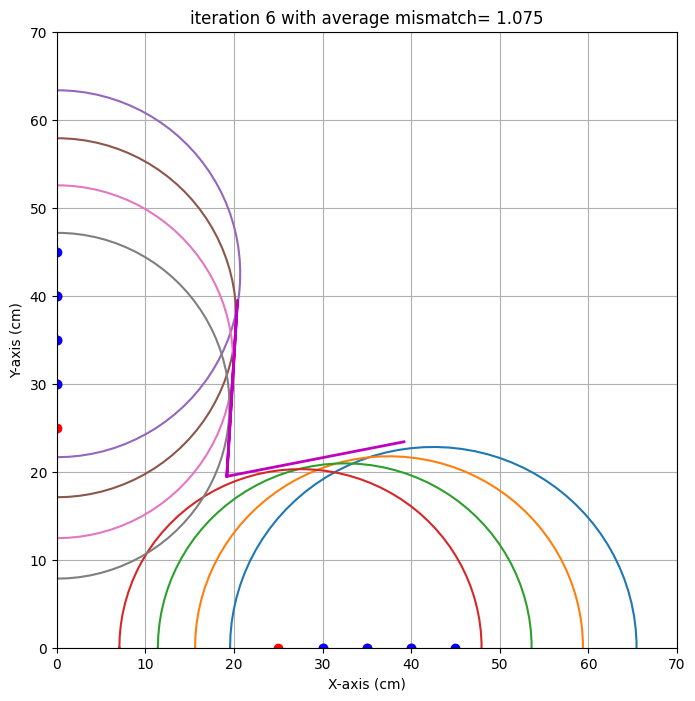

end iteration 6 with average mismatch= 1.075


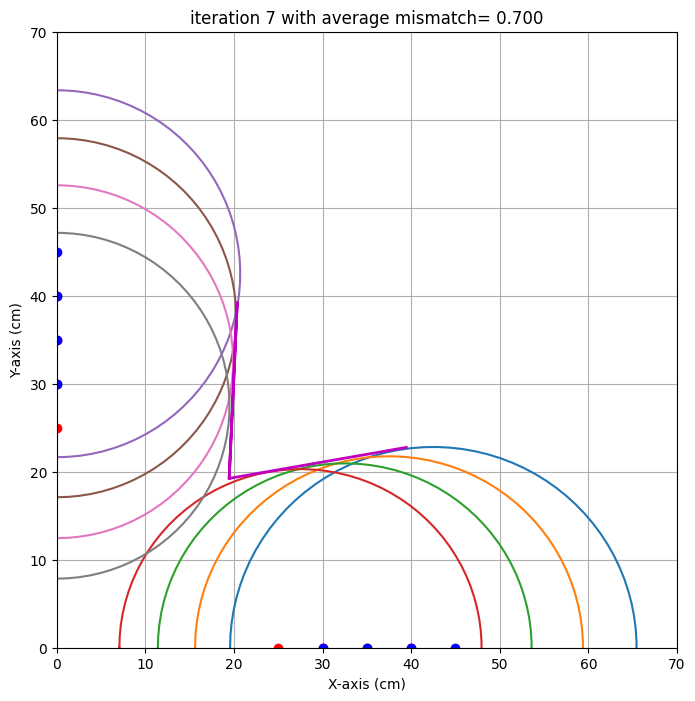

end iteration 7 with average mismatch= 0.700
end iteration 8 with average mismatch= 0.691
end iteration 9 with average mismatch= 0.691
end iteration 10 with average mismatch= 0.691
end iteration 11 with average mismatch= 0.691
end iteration 12 with average mismatch= 0.691
end iteration 13 with average mismatch= 0.691
end iteration 14 with average mismatch= 0.691
end iteration 15 with average mismatch= 0.691
end iteration 16 with average mismatch= 0.691
end iteration 17 with average mismatch= 0.691
end iteration 18 with average mismatch= 0.691
end iteration 19 with average mismatch= 0.691
end iteration 20 with average mismatch= 0.683
end iteration 21 with average mismatch= 0.683
end iteration 22 with average mismatch= 0.683
end iteration 23 with average mismatch= 0.683
end iteration 24 with average mismatch= 0.683
end iteration 25 with average mismatch= 0.683
end iteration 26 with average mismatch= 0.683
end iteration 27 with average mismatch= 0.683
end iteration 28 with average mismatc

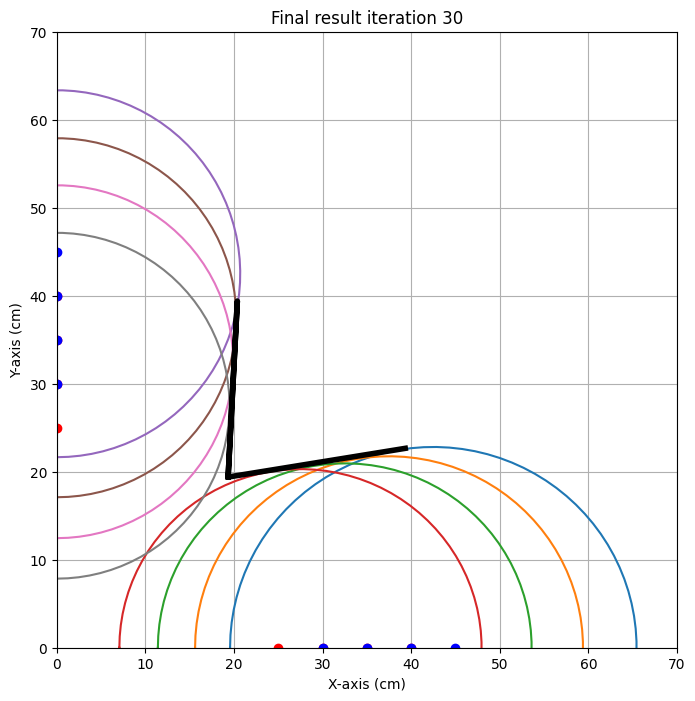

{'alpha': np.float64(9.2667797245109), 'alpha_eps': 0.0, 'beta': np.float64(2.9866993538452054), 'beta_eps': 0.0, 'x0': np.float64(19.328683722550213), 'x0_eps': 0.0, 'y0': np.float64(19.393646599915446), 'y0_eps': 0.0}
Carsten


KeyError: 'Carsten'

In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Sriman 
x0 target is : 20.0. Gevonden waarde: 19.1 cm met een standaardafwijking van 0.0 cm 
y0 target is : 20.0. Gevonden waarde: 22.4 cm met een standaardafwijking van 0.5 cm 
alpha target is : 10.0. Gevonden waarde: -6.3 graden met een standaardafwijking van 3.6 graad 
beta target is : 5.0. Gevonden waarde: 10.9 graden met een standaardafwijking van 2.1 graad 

Juraj 
x0 target is : 20.0. Gevonden waarde: 19.2 cm met een standaardafwijking van 0.9 cm 
y0 target is : 20.0. Gevonden waarde: 19.4 cm met een standaardafwijking van 0.2 cm 
alpha target is : 10.0. Gevonden waarde: 8.9 graden met een standaardafwijking van 2.1 graad 
beta target is : 5.0. Gevonden waarde: 3.4 graden met een standaardafwijking van 2.8 graad 



KeyError: 'Carsten'

## Opdracht 8: Iteratie1+16.29.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](It1.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':,
                    'y0':,
                    'alpha' :,
                    'beta' :,
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (3018683157.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")